<a href="https://colab.research.google.com/github/alveana/Gait-Angle-Difference-Analysis-/blob/main/GaitAngleDifferenceAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Statistical Analysis - Gait Angle Difference Analysis (GADA)

Goal: Find which joint angles significantly changes between baseline and adjusted gait using hypothesis testing.


In [34]:
# ============================================================
# CELL 1: SHARED DATA LOADING AND PREPROCESSING
# Used by Methods 1, 2, and 3
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
from google.colab import drive


drive.mount("/content/drive")

# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------

data_folder = "/content/drive/MyDrive/Import Data"

baseline_event_path = (
    f"{data_folder}/Gait_Event_Segmentation_Baseline.xlsx"
)

adjusted_event_path = (
    f"{data_folder}/Gait_Event_Segmentation_Adjusted.xlsx"
)

baseline_angle_path = (
    f"{data_folder}/LeftAnkle_Angle_normal_steps.xlsx"
)

adjusted_angle_path = (
    f"{data_folder}/LeftAnkle_Angle_adjusted_steps.xlsx"
)

# ------------------------------------------------------------
# Load event data
# ------------------------------------------------------------

target_sheets = [
    "Heel_Contact",
    "Toe_Contact",
    "Heel_Off",
    "Toe_Off"
]

baseline_event_sheets = pd.read_excel(
    baseline_event_path,
    sheet_name=target_sheets
)

adjusted_event_sheets = pd.read_excel(
    adjusted_event_path,
    sheet_name=target_sheets
)

# Preserve worksheet names as the Event variable
baseline_events = pd.concat(
    [
        sheet_data.assign(Event=sheet_name)
        for sheet_name, sheet_data
        in baseline_event_sheets.items()
    ],
    ignore_index=True
)
baseline_events["Condition"] = "baseline"

adjusted_events = pd.concat(
    [
        sheet_data.assign(Event=sheet_name)
        for sheet_name, sheet_data
        in adjusted_event_sheets.items()
    ],
    ignore_index=True
)
adjusted_events["Condition"] = "adjusted"

events_df = pd.concat(
    [baseline_events, adjusted_events],
    ignore_index=True
)

# ------------------------------------------------------------
# Load continuous frame-level angle data
# ------------------------------------------------------------

baseline_angles = pd.read_excel(baseline_angle_path)
adjusted_angles = pd.read_excel(adjusted_angle_path)

# Keep labels identical across both data tables
baseline_angles["Condition"] = "baseline"
adjusted_angles["Condition"] = "adjusted"

continuous_df = pd.concat(
    [baseline_angles, adjusted_angles],
    ignore_index=True
)

# ------------------------------------------------------------
# Convert required columns to numeric
# ------------------------------------------------------------

continuous_numeric_columns = [
    "Frame",
    "X",
    "Y",
    "Z",
    "Set_Number"
]

for column in continuous_numeric_columns:
    continuous_df[column] = pd.to_numeric(
        continuous_df[column],
        errors="coerce"
    )

event_numeric_columns = [
    "Event_Frame",
    "X",
    "Y",
    "Z",
    "Set_Number",
    "Step"
]

for column in event_numeric_columns:
    events_df[column] = pd.to_numeric(
        events_df[column],
        errors="coerce"
    )

# ------------------------------------------------------------
# Remove rows missing essential identifiers
# ------------------------------------------------------------

events_df = events_df.dropna(
    subset=[
        "Condition",
        "Event",
        "Event_Frame",
        "Set_Number",
        "Step"
    ]
).copy()

continuous_df = continuous_df.dropna(
    subset=[
        "Condition",
        "Frame",
        "Set_Number"
    ]
).copy()

# ------------------------------------------------------------
# Sort chronologically
# ------------------------------------------------------------

events_df = events_df.sort_values(
    [
        "Condition",
        "Set_Number",
        "Event_Frame"
    ]
).reset_index(drop=True)

continuous_df = continuous_df.sort_values(
    [
        "Condition",
        "Set_Number",
        "Frame"
    ]
).reset_index(drop=True)

# ------------------------------------------------------------
# Initial checks
# ------------------------------------------------------------

print("Event data shape:", events_df.shape)
print("Continuous data shape:", continuous_df.shape)

print("\nConditions in event data:")
print(events_df["Condition"].value_counts())

print("\nConditions in continuous data:")
print(continuous_df["Condition"].value_counts())

print("\nEvents loaded:")
print(events_df["Event"].value_counts())

display(events_df.head())
display(continuous_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Event data shape: (288, 8)
Continuous data shape: (8199, 6)

Conditions in event data:
Condition
adjusted    160
baseline    128
Name: count, dtype: int64

Conditions in continuous data:
Condition
adjusted    4573
baseline    3626
Name: count, dtype: int64

Events loaded:
Event
Heel_Contact    72
Toe_Contact     72
Heel_Off        72
Toe_Off         72
Name: count, dtype: int64


,Step,Event,Event_Frame,X,Y,Z,Set_Number,Condition
0,2,Heel_Contact,305,-85.786781,-28.896393,-17.848001,1,adjusted
1,2,Toe_Contact,335,-83.196770,-17.288385,-5.429987,1,adjusted
2,2,Heel_Off,350,-86.644188,-19.232719,-6.556606,1,adjusted
3,2,Toe_Off,372,-44.291836,-21.804281,-3.051869,1,adjusted
4,3,Heel_Contact,415,-85.781982,-26.342434,-15.677832,1,adjusted


,Frame,X,Y,Z,Condition,Set_Number
0,305,-85.786781,-28.896393,-17.848001,adjusted,1
1,306,-83.406723,-30.892960,-14.481898,adjusted,1
2,307,-77.358643,-33.293690,-9.512656,adjusted,1
3,308,-72.627762,-30.235899,-6.751798,adjusted,1
4,309,-70.122551,-24.166424,-7.036766,adjusted,1


In [23]:
# ============================================================
# CELL 2: SHARED CONSTANTS AND DATA VALIDATION
# ============================================================

angles = ["X", "Y", "Z"]

event_order = [
    "Heel_Contact",
    "Toe_Contact",
    "Heel_Off",
    "Toe_Off"
]

phase_order = [
    "Heel Contact → Toe Contact",
    "Toe Contact → Heel Off",
    "Heel Off → Toe Off",
    "Toe Off → Next Heel Contact"
]

required_event_columns = {
    "Condition",
    "Set_Number",
    "Step",
    "Event",
    "Event_Frame",
    "X",
    "Y",
    "Z"
}

required_continuous_columns = {
    "Condition",
    "Set_Number",
    "Frame",
    "X",
    "Y",
    "Z"
}

missing_event_columns = (
    required_event_columns - set(events_df.columns)
)

missing_continuous_columns = (
    required_continuous_columns - set(continuous_df.columns)
)

if missing_event_columns:
    raise ValueError(
        f"Missing event-data columns: {missing_event_columns}"
    )

if missing_continuous_columns:
    raise ValueError(
        "Missing continuous-data columns: "
        f"{missing_continuous_columns}"
    )

print("Validation passed.")
print("Event conditions:", events_df["Condition"].unique())
print(
    "Continuous conditions:",
    continuous_df["Condition"].unique()
)
print("Events:", events_df["Event"].unique())

Validation passed.
Event conditions: ['adjusted' 'baseline']
Continuous conditions: ['adjusted' 'baseline']
Events: ['Heel_Contact' 'Toe_Contact' 'Heel_Off' 'Toe_Off']


# Method 1 - Event-Point Analysis
This method uses the angle recorded exactly when each event occured.

Focusing on answering:
- Are X, Y, or Z different at Heel Contact, Toe Contact, Heel Off, or Toe Off?


In [24]:
# ============================================================
# METHOD 1: EVENT-POINT JOINT-ANGLE ANALYSIS
# ============================================================
# Calculate event-point results
method_1_results = []

for event in event_order:

    event_data = df[df["Event"] == event]

    for angle in angles:

        baseline_values = event_data.loc[
            event_data["Condition"] == "baseline",
            angle
        ].dropna()

        adjusted_values = event_data.loc[
            event_data["Condition"] == "adjusted",
            angle
        ].dropna()

        if len(baseline_values) < 2 or len(adjusted_values) < 2:
            continue

        f_statistic, p_value = f_oneway(
            baseline_values,
            adjusted_values
        )

        combined = np.concatenate([
            baseline_values,
            adjusted_values
        ])

        grand_mean = combined.mean()

        ss_between = (
            len(baseline_values)
            * (baseline_values.mean() - grand_mean) ** 2
            +
            len(adjusted_values)
            * (adjusted_values.mean() - grand_mean) ** 2
        )

        ss_total = np.sum((combined - grand_mean) ** 2)

        eta_squared = (
            ss_between / ss_total
            if ss_total > 0
            else np.nan
        )

        method_1_results.append({
            "Event": event,
            "Axis": angle,
            "Baseline_Mean": baseline_values.mean(),
            "Adjusted_Mean": adjusted_values.mean(),
            "Change": (
                adjusted_values.mean()
                - baseline_values.mean()
            ),
            "F_Statistic": f_statistic,
            "Raw_P_Value": p_value,
            "Eta_Squared": eta_squared,
            "Baseline_N": len(baseline_values),
            "Adjusted_N": len(adjusted_values)
        })

method_1_results = pd.DataFrame(method_1_results)

if not method_1_results.empty:

    rejected, corrected_p, _, _ = multipletests(
        method_1_results["Raw_P_Value"],
        alpha=0.05,
        method="fdr_bh"
    )

    method_1_results["FDR_P_Value"] = corrected_p
    method_1_results["FDR_Significant"] = rejected

    method_1_results = method_1_results.sort_values(
        "FDR_P_Value"
    ).reset_index(drop=True)

display(method_1_results)

,Event,Axis,Baseline_Mean,Adjusted_Mean,Change,F_Statistic,Raw_P_Value,Eta_Squared,Baseline_N,Adjusted_N,FDR_P_Value,FDR_Significant
0,Heel_Contact,X,-78.912211,-79.008392,-0.096181,0.016734,0.897445,0.000239,32,40,0.99304,False
1,Heel_Contact,Y,-27.922902,-27.577337,0.345565,0.603569,0.439837,0.008549,32,40,0.99304,False
2,Heel_Contact,Z,-13.575568,-13.529810,0.045758,0.008203,0.928093,0.000117,32,40,0.99304,False
3,Toe_Contact,X,-81.470363,-81.493846,-0.023483,0.002427,0.960853,0.000035,32,40,0.99304,False
4,Toe_Contact,Y,-17.958136,-17.954730,0.003406,0.000077,0.993040,0.000001,32,40,0.99304,False
5,Toe_Contact,Z,-7.169090,-7.155984,0.013106,0.003093,0.955805,0.000044,32,40,0.99304,False
6,Heel_Off,X,-91.320189,-91.003754,0.316434,0.539409,0.465131,0.007647,32,40,0.99304,False
7,Heel_Off,Y,-22.224852,-22.319441,-0.094589,0.040280,0.841516,0.000575,32,40,0.99304,False
8,Heel_Off,Z,-12.257091,-12.225985,0.031105,0.008295,0.927691,0.000118,32,40,0.99304,False
9,Toe_Off,X,-50.711485,-49.898052,0.813432,1.402565,0.240300,0.019643,32,40,0.99304,False


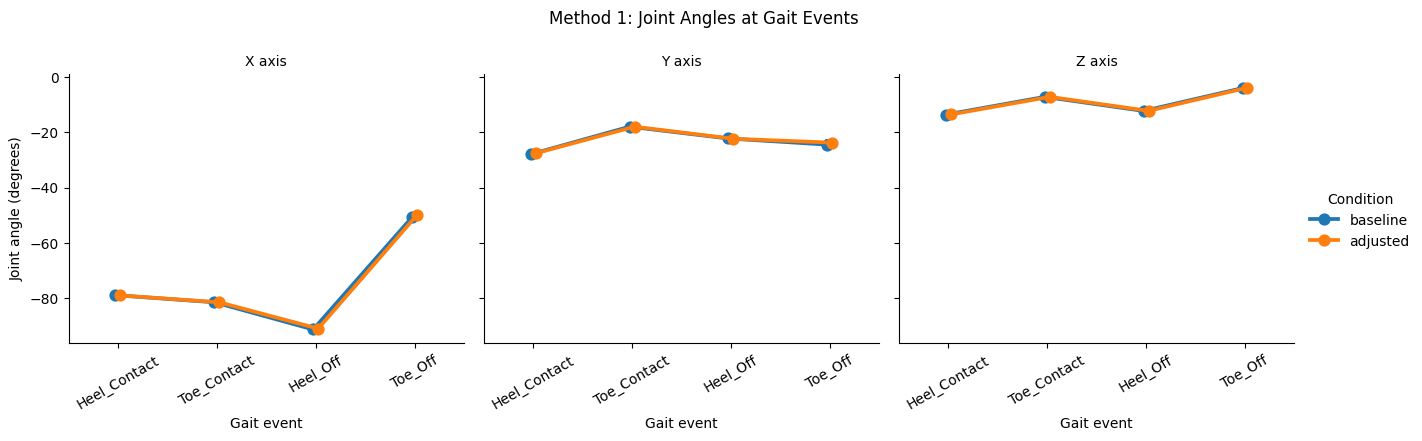

In [25]:
# ============================================================
# METHOD 1 VISUALIZATION
# ============================================================

method_1_plot_data = df.melt(
    id_vars=[
        "Condition",
        "Set_Number",
        "Step",
        "Event"
    ],
    value_vars=angles,
    var_name="Axis",
    value_name="Event_Angle"
)

g = sns.catplot(
    data=method_1_plot_data,
    x="Event",
    y="Event_Angle",
    hue="Condition",
    col="Axis",
    kind="point",
    errorbar=("ci", 95),
    dodge=True,
    height=4,
    aspect=1.1
)

g.set_axis_labels(
    "Gait event",
    "Joint angle (degrees)"
)

g.set_titles("{col_name} axis")
g.fig.subplots_adjust(top=0.82)
g.fig.suptitle(
    "Method 1: Joint Angles at Gait Events"
)

for axis_plot in g.axes.flat:
    axis_plot.tick_params(axis="x", rotation=30)

plt.show()

# Method 2 - Phase-avarage analysis
This method uses every continuous frame between two events.



In [26]:
# ============================================================
# METHOD 2: PREPARE GAIT-PHASE BOUNDARIES
# ============================================================

event_table = df.pivot_table(
    index=["Condition", "Set_Number", "Step"],
    columns="Event",
    values="Event_Frame",
    aggfunc="first"
).reset_index()

event_table = event_table.sort_values(
    ["Condition", "Set_Number", "Step"]
).reset_index(drop=True)

display(event_table.head())



Event,Condition,Set_Number,Step,Heel_Contact,Heel_Off,Toe_Contact,Toe_Off
0,adjusted,1,2,305,350,335,372
1,adjusted,1,3,415,466,445,487
2,adjusted,1,4,532,582,562,605
3,adjusted,1,5,646,697,676,722
4,adjusted,1,6,757,810,787,834


In [29]:
# ============================================================
# METHOD 2: EXTRACT PHASE-AVERAGE ANGLES
# ============================================================

method_2_rows = []


def add_phase_mean(
    condition,
    set_number,
    step,
    phase,
    start_frame,
    end_frame
):
    if pd.isna(start_frame) or pd.isna(end_frame):
        return

    start_frame = int(start_frame)
    end_frame = int(end_frame)

    if end_frame <= start_frame:
        return

    # End frame is excluded to prevent adjacent phases
    # from counting the same frame twice.
    phase_frames = continuous_df[
        (continuous_df["Condition"] == condition)
        & (continuous_df["Set_Number"] == set_number)
        & (continuous_df["Frame"] >= start_frame)
        & (continuous_df["Frame"] < end_frame)
    ]

    if phase_frames.empty:
        return

    row = {
        "Condition": condition,
        "Set_Number": set_number,
        "Step": step,
        "Phase": phase,
        "Start_Frame": start_frame,
        "End_Frame": end_frame,
        "Frame_Count": len(phase_frames)
    }

    for angle in angles:
        row[f"{angle}_Mean"] = phase_frames[angle].mean()

    method_2_rows.append(row)


for (condition, set_number), set_table in event_table.groupby(
    ["Condition", "Set_Number"]
):
    set_table = set_table.sort_values("Step").reset_index(drop=True)

    for row_number, event_row in set_table.iterrows():

        step = event_row["Step"]

        add_phase_mean(
            condition,
            set_number,
            step,
            "Heel Contact → Toe Contact",
            event_row.get("Heel_Contact"),
            event_row.get("Toe_Contact")
        )

        add_phase_mean(
            condition,
            set_number,
            step,
            "Toe Contact → Heel Off",
            event_row.get("Toe_Contact"),
            event_row.get("Heel_Off")
        )

        add_phase_mean(
            condition,
            set_number,
            step,
            "Heel Off → Toe Off",
            event_row.get("Heel_Off"),
            event_row.get("Toe_Off")
        )

        # The fourth phase requires the next step's Heel Contact
        if row_number < len(set_table) - 1:
            next_heel_contact = set_table.loc[
                row_number + 1,
                "Heel_Contact"
            ]

            add_phase_mean(
                condition,
                set_number,
                step,
                "Toe Off → Next Heel Contact",
                event_row.get("Toe_Off"),
                next_heel_contact
            )

method_2_features = pd.DataFrame(method_2_rows)

method_2_features["Phase"] = pd.Categorical(
    method_2_features["Phase"],
    categories=phase_order,
    ordered=True
)

method_2_features = method_2_features.sort_values(
    ["Condition", "Set_Number", "Step", "Phase"]
).reset_index(drop=True)

print("Method 2 phase observations:", len(method_2_features))
display(method_2_features.head(12))

Method 2 phase observations: 279


,Condition,Set_Number,Step,Phase,Start_Frame,End_Frame,Frame_Count,X_Mean,Y_Mean,Z_Mean
0,adjusted,1,2,Heel Contact → Toe Contact,305,335,30,-78.100578,-18.810477,-6.754412
1,adjusted,1,2,Toe Contact → Heel Off,335,350,15,-85.121572,-17.706328,-5.701843
2,adjusted,1,2,Heel Off → Toe Off,350,372,22,-72.241929,-25.767872,-5.566750
3,adjusted,1,2,Toe Off → Next Heel Contact,372,415,43,-70.126989,-26.659930,-5.265749
4,adjusted,1,3,Heel Contact → Toe Contact,415,445,30,-78.253666,-18.878189,-6.203968
5,adjusted,1,3,Toe Contact → Heel Off,445,466,21,-83.857070,-21.048070,-6.782312
6,adjusted,1,3,Heel Off → Toe Off,466,487,21,-72.091845,-29.551045,-7.996369
7,adjusted,1,3,Toe Off → Next Heel Contact,487,532,45,-75.734415,-25.581556,-10.332724
8,adjusted,1,4,Heel Contact → Toe Contact,532,562,30,-79.134227,-21.146050,-8.518999
9,adjusted,1,4,Toe Contact → Heel Off,562,582,20,-84.805793,-22.715231,-8.558845


In [30]:
# ============================================================
# METHOD 2: PHASE-AVERAGE STATISTICAL COMPARISON
# ============================================================

method_2_results = []

for phase in phase_order:

    phase_data = method_2_features[
        method_2_features["Phase"] == phase
    ]

    for angle in angles:

        outcome = f"{angle}_Mean"

        baseline_values = phase_data.loc[
            phase_data["Condition"] == "baseline",
            outcome
        ].dropna()

        adjusted_values = phase_data.loc[
            phase_data["Condition"] == "adjusted",
            outcome
        ].dropna()

        if len(baseline_values) < 2 or len(adjusted_values) < 2:
            continue

        f_statistic, p_value = f_oneway(
            baseline_values,
            adjusted_values
        )

        method_2_results.append({
            "Phase": phase,
            "Axis": angle,
            "Baseline_Mean": baseline_values.mean(),
            "Adjusted_Mean": adjusted_values.mean(),
            "Change": (
                adjusted_values.mean()
                - baseline_values.mean()
            ),
            "F_Statistic": f_statistic,
            "Raw_P_Value": p_value,
            "Baseline_N": len(baseline_values),
            "Adjusted_N": len(adjusted_values)
        })

method_2_results = pd.DataFrame(method_2_results)

if not method_2_results.empty:

    rejected, corrected_p, _, _ = multipletests(
        method_2_results["Raw_P_Value"],
        alpha=0.05,
        method="fdr_bh"
    )

    method_2_results["FDR_P_Value"] = corrected_p
    method_2_results["FDR_Significant"] = rejected

    method_2_results = method_2_results.sort_values(
        "FDR_P_Value"
    ).reset_index(drop=True)

display(method_2_results)

,Phase,Axis,Baseline_Mean,Adjusted_Mean,Change,F_Statistic,Raw_P_Value,Baseline_N,Adjusted_N,FDR_P_Value,FDR_Significant
0,Heel Contact → Toe Contact,X,-76.279400,-76.249876,0.029524,0.002566,0.959746,32,40,0.959746,False
1,Heel Contact → Toe Contact,Y,-19.725502,-19.658938,0.066563,0.049602,0.824407,32,40,0.959746,False
2,Heel Contact → Toe Contact,Z,-7.116615,-7.056573,0.060043,0.050744,0.822430,32,40,0.959746,False
3,Toe Contact → Heel Off,X,-85.386306,-85.205410,0.180896,0.451861,0.503665,32,40,0.959746,False
4,Toe Contact → Heel Off,Y,-19.572050,-19.636182,-0.064132,0.023143,0.879523,32,40,0.959746,False
5,Toe Contact → Heel Off,Z,-8.587273,-8.566968,0.020305,0.006658,0.935200,32,40,0.959746,False
6,Heel Off → Toe Off,X,-73.474303,-73.144818,0.329485,0.762092,0.385659,32,40,0.959746,False
7,Heel Off → Toe Off,Y,-29.092260,-28.984609,0.107652,0.045788,0.831184,32,40,0.959746,False
8,Heel Off → Toe Off,Z,-9.792769,-9.721453,0.071316,0.047877,0.827437,32,40,0.959746,False
9,Toe Off → Next Heel Contact,X,-73.501216,-73.018171,0.483045,1.033745,0.313296,28,35,0.959746,False


# Method 3 - Continous Peaks and Range of Motion
This section independently extracts:
- Positive Peak
- Negative Peak
- Absolute Peak Magnitude
- Range of Motion
- Dominant Peak Direction


In [31]:
# ============================================================
# METHOD 3: CONTINUOUS PEAK AND ROM EXTRACTION
# ============================================================

method_3_rows = []


def add_peak_features(
    condition,
    set_number,
    step,
    phase,
    start_frame,
    end_frame
):
    if pd.isna(start_frame) or pd.isna(end_frame):
        return

    start_frame = int(start_frame)
    end_frame = int(end_frame)

    if end_frame <= start_frame:
        return

    phase_frames = continuous_df[
        (continuous_df["Condition"] == condition)
        & (continuous_df["Set_Number"] == set_number)
        & (continuous_df["Frame"] >= start_frame)
        & (continuous_df["Frame"] < end_frame)
    ]

    if phase_frames.empty:
        return

    row = {
        "Condition": condition,
        "Set_Number": set_number,
        "Step": step,
        "Phase": phase,
        "Start_Frame": start_frame,
        "End_Frame": end_frame,
        "Frame_Count": len(phase_frames)
    }

    for angle in angles:

        values = phase_frames[angle].dropna()

        if values.empty:
            continue

        positive_peak = values.max()
        negative_peak = values.min()

        if abs(positive_peak) >= abs(negative_peak):
            absolute_peak = abs(positive_peak)
            dominant_direction = "Positive"
        else:
            absolute_peak = abs(negative_peak)
            dominant_direction = "Negative"

        row[f"{angle}_Positive_Peak"] = positive_peak
        row[f"{angle}_Negative_Peak"] = negative_peak
        row[f"{angle}_Absolute_Peak"] = absolute_peak
        row[f"{angle}_ROM"] = positive_peak - negative_peak
        row[f"{angle}_Direction"] = dominant_direction

    method_3_rows.append(row)


for (condition, set_number), set_table in event_table.groupby(
    ["Condition", "Set_Number"]
):
    set_table = set_table.sort_values("Step").reset_index(drop=True)

    for row_number, event_row in set_table.iterrows():

        step = event_row["Step"]

        phase_definitions = [
            (
                "Heel Contact → Toe Contact",
                event_row.get("Heel_Contact"),
                event_row.get("Toe_Contact")
            ),
            (
                "Toe Contact → Heel Off",
                event_row.get("Toe_Contact"),
                event_row.get("Heel_Off")
            ),
            (
                "Heel Off → Toe Off",
                event_row.get("Heel_Off"),
                event_row.get("Toe_Off")
            )
        ]

        if row_number < len(set_table) - 1:
            phase_definitions.append(
                (
                    "Toe Off → Next Heel Contact",
                    event_row.get("Toe_Off"),
                    set_table.loc[
                        row_number + 1,
                        "Heel_Contact"
                    ]
                )
            )

        for phase, start_frame, end_frame in phase_definitions:
            add_peak_features(
                condition,
                set_number,
                step,
                phase,
                start_frame,
                end_frame
            )

method_3_features = pd.DataFrame(method_3_rows)

method_3_features["Phase"] = pd.Categorical(
    method_3_features["Phase"],
    categories=phase_order,
    ordered=True
)

method_3_features = method_3_features.sort_values(
    ["Condition", "Set_Number", "Step", "Phase"]
).reset_index(drop=True)

print("Method 3 phase observations:", len(method_3_features))
display(method_3_features.head(12))

Method 3 phase observations: 279


,Condition,Set_Number,Step,Phase,Start_Frame,End_Frame,Frame_Count,X_Positive_Peak,X_Negative_Peak,X_Absolute_Peak,...,Y_Positive_Peak,Y_Negative_Peak,Y_Absolute_Peak,Y_ROM,Y_Direction,Z_Positive_Peak,Z_Negative_Peak,Z_Absolute_Peak,Z_ROM,Z_Direction
0,adjusted,1,2,Heel Contact → Toe Contact,305,335,30,-68.426460,-85.786781,85.786781,...,-12.861674,-33.293690,33.293690,20.432016,Negative,-4.627462,-17.848001,17.848001,13.220539,Negative
1,adjusted,1,2,Toe Contact → Heel Off,335,350,15,-83.196770,-86.486305,86.486305,...,-17.011925,-18.932682,18.932682,1.920757,Negative,-5.381769,-6.268003,6.268003,0.886234,Negative
2,adjusted,1,2,Heel Off → Toe Off,350,372,22,-42.220070,-86.797676,86.797676,...,-19.232719,-36.830017,36.830017,17.597298,Negative,5.953454,-12.505036,12.505036,18.458490,Negative
3,adjusted,1,2,Toe Off → Next Heel Contact,372,415,43,-44.291836,-86.652336,86.652336,...,-21.569323,-34.492401,34.492401,12.923078,Negative,3.811153,-19.974304,19.974304,23.785457,Negative
4,adjusted,1,3,Heel Contact → Toe Contact,415,445,30,-70.888809,-85.781982,85.781982,...,-15.617679,-29.334652,29.334652,13.716973,Negative,-3.990801,-15.677832,15.677832,11.687031,Negative
5,adjusted,1,3,Toe Contact → Heel Off,445,466,21,-82.329826,-85.934074,85.934074,...,-18.844053,-23.298653,23.298653,4.454600,Negative,-5.405590,-9.366444,9.366444,3.960854,Negative
6,adjusted,1,3,Heel Off → Toe Off,466,487,21,-42.824780,-87.056435,87.056435,...,-23.477043,-40.215717,40.215717,16.738674,Negative,4.382007,-15.399335,15.399335,19.781342,Negative
7,adjusted,1,3,Toe Off → Next Heel Contact,487,532,45,-46.166782,-86.753372,86.753372,...,-22.766075,-28.171034,28.171034,5.404959,Negative,-4.152365,-19.862419,19.862419,15.710054,Negative
8,adjusted,1,4,Heel Contact → Toe Contact,532,562,30,-73.800209,-86.528603,86.528603,...,-16.959724,-31.714157,31.714157,14.754433,Negative,-6.750546,-17.333204,17.333204,10.582658,Negative
9,adjusted,1,4,Toe Contact → Heel Off,562,582,20,-82.158226,-87.868515,87.868515,...,-20.478037,-24.837959,24.837959,4.359922,Negative,-7.253119,-10.168528,10.168528,2.915409,Negative


In [32]:
# ============================================================
# METHOD 3: PEAK AND ROM STATISTICAL COMPARISON
# ============================================================

peak_outcomes = [
    "Positive_Peak",
    "Negative_Peak",
    "Absolute_Peak",
    "ROM"
]

method_3_results = []

for phase in phase_order:

    phase_data = method_3_features[
        method_3_features["Phase"] == phase
    ]

    for angle in angles:

        for peak_outcome in peak_outcomes:

            column = f"{angle}_{peak_outcome}"

            baseline_values = phase_data.loc[
                phase_data["Condition"] == "baseline",
                column
            ].dropna()

            adjusted_values = phase_data.loc[
                phase_data["Condition"] == "adjusted",
                column
            ].dropna()

            if len(baseline_values) < 2 or len(adjusted_values) < 2:
                continue

            f_statistic, p_value = f_oneway(
                baseline_values,
                adjusted_values
            )

            method_3_results.append({
                "Phase": phase,
                "Axis": angle,
                "Feature": peak_outcome,
                "Baseline_Mean": baseline_values.mean(),
                "Adjusted_Mean": adjusted_values.mean(),
                "Change": (
                    adjusted_values.mean()
                    - baseline_values.mean()
                ),
                "F_Statistic": f_statistic,
                "Raw_P_Value": p_value,
                "Baseline_N": len(baseline_values),
                "Adjusted_N": len(adjusted_values)
            })

method_3_results = pd.DataFrame(method_3_results)

if not method_3_results.empty:

    rejected, corrected_p, _, _ = multipletests(
        method_3_results["Raw_P_Value"],
        alpha=0.05,
        method="fdr_bh"
    )

    method_3_results["FDR_P_Value"] = corrected_p
    method_3_results["FDR_Significant"] = rejected

    method_3_results = method_3_results.sort_values(
        "FDR_P_Value"
    ).reset_index(drop=True)

display(method_3_results)

,Phase,Axis,Feature,Baseline_Mean,Adjusted_Mean,Change,F_Statistic,Raw_P_Value,Baseline_N,Adjusted_N,FDR_P_Value,FDR_Significant
0,Heel Contact → Toe Contact,X,Positive_Peak,-68.496152,-68.140381,0.355771,0.153266,0.696623,32,40,0.997384,False
1,Heel Contact → Toe Contact,X,Negative_Peak,-81.534894,-81.762975,-0.228081,0.155049,0.694953,32,40,0.997384,False
2,Heel Contact → Toe Contact,X,Absolute_Peak,81.534894,81.762975,0.228081,0.155049,0.694953,32,40,0.997384,False
3,Heel Contact → Toe Contact,X,ROM,13.038742,13.622594,0.583852,1.161667,0.284820,32,40,0.997384,False
4,Heel Contact → Toe Contact,Y,Positive_Peak,-15.730627,-15.763071,-0.032444,0.006487,0.936034,32,40,0.997384,False
5,Heel Contact → Toe Contact,Y,Negative_Peak,-30.520813,-30.157463,0.363350,0.758694,0.386715,32,40,0.997384,False
6,Heel Contact → Toe Contact,Y,Absolute_Peak,30.520813,30.157463,-0.363350,0.758694,0.386715,32,40,0.997384,False
7,Heel Contact → Toe Contact,Y,ROM,14.790186,14.394391,-0.395794,0.472825,0.493963,32,40,0.997384,False
8,Heel Contact → Toe Contact,Z,Positive_Peak,-4.666935,-4.501107,0.165828,0.176030,0.676092,32,40,0.997384,False
9,Heel Contact → Toe Contact,Z,Negative_Peak,-13.628667,-13.536448,0.092219,0.035512,0.851072,32,40,0.997384,False


In [33]:
# ============================================================
# EXPORT ALL METHOD RESULTS
# ============================================================

method_1_results.to_csv(
    "method_1_event_point_results.csv",
    index=False
)

method_2_features.to_csv(
    "method_2_phase_features.csv",
    index=False
)

method_2_results.to_csv(
    "method_2_phase_average_results.csv",
    index=False
)

method_3_features.to_csv(
    "method_3_peak_features.csv",
    index=False
)

method_3_results.to_csv(
    "method_3_peak_results.csv",
    index=False
)

print("All results were exported successfully.")

All results were exported successfully.
